# Stage 4 — Sparse Jump Model (SJM) regime signal

Reproduction of Stage 4 of **Shu & Mulvey (2024)**, *Dynamic Factor Allocation Leveraging Regime-Switching Signals*.

Fits the author's **Sparse Jump Model** (`jumpmodels` library) per factor and produces a daily bull/bear regime signal, then evaluates signal quality with the paper's single-factor long-short test (Exhibit 6).

**Steps** (run top to bottom; each step prints a sanity summary and there is a `PAUSE` marker where the spec asks you to confirm before continuing):
1. Load & confirm inputs.
2. Train-only preprocessing utility (clip + standardize).
3. Single prototype fit on momentum (fixed hyper-params), in-sample regimes.
4. Online walk-forward with monthly refit → `signals.parquet` (all 6 factors).
5. Long-short signal-quality evaluation → `longshort_eval.parquet`.

**Strictly no look-ahead:** scaler + SJM are fit on training data only; the live signal is shifted forward before it is used.

Black-Litterman (Stage 6) is intentionally **not** built here.

In [1]:
# ----------------------------------------------------------------------
# 0. Imports & configuration
# ----------------------------------------------------------------------
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from importlib.metadata import version

from jumpmodels.preprocess import StandardScalerPD, DataClipperStd
from jumpmodels.sparse_jump import SparseJumpModel

warnings.filterwarnings("ignore")
print("jumpmodels version:", version("jumpmodels"))

# --- The 6 factors ---
FACTORS = ["value", "size", "momentum", "quality", "lowvol", "growth"]

# --- Stage-3 outputs live in this folder (root), not a features/ subdir ---
DATA_DIR = "."

# --- SJM hyper-parameters (fixed for Stage 4; tuning is a later step) ---
N_COMPONENTS = 2
JUMP_PENALTY = 50.0
MAX_FEATS    = 10.0
RANDOM_STATE = 0

# --- Preprocessing ---
CLIP_MUL = 3.0          # DataClipperStd: clip raw features at +/- 3 std (train std)

# --- Walk-forward (Step 4) ---
TEST_START          = pd.Timestamp("2007-01-01")  # 1999-2006 = burn-in
MAX_LOOKBACK_YEARS  = 12                          # cap the expanding window at 12y
MIN_TRAIN_YEARS     = 8                           # nominal minimum train length
REFIT_FREQ          = "M"                          # refit monthly ('Q' = quarterly, faster)
SIGNAL_DELAY        = 2                            # regime inferred end-of-T used from T+2

# --- Evaluation (Step 5) ---
ANNUAL        = 252
RET_CAP       = 0.05      # +/-5%/yr expected active return -> +/-100% position
COST_PER_SIDE = 0.0005   # 5 bps per side on position changes

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

Matplotlib is building the font cache; this may take a moment.


jumpmodels version: 0.1.1


## Step 1 — Load and confirm
Load all 6 feature tables + `active_returns.parquet`; print shapes, date ranges, confirm 0 NaNs.

`active_returns.parquet` keeps its raw scattered NaNs (momentum ~22, growth ~250). For every use here it is re-indexed to a factor's feature index and missing days are filled with `0.0` (no active move), matching the Stage-3 treatment.

In [2]:
# Feature tables: one DataFrame per factor (DatetimeIndex 'date', 17 cols, 0 NaN).
features = {f: pd.read_parquet(f"{DATA_DIR}/{f}.parquet") for f in FACTORS}

# Raw active returns (factor - market).
active_raw = pd.read_parquet(f"{DATA_DIR}/active_returns.parquet")

# Per-factor active returns aligned to that factor's feature index, gaps -> 0.
active = {f: active_raw[f].reindex(features[f].index).fillna(0.0) for f in FACTORS}

print("==== FEATURE TABLES ====")
for f in FACTORS:
    df = features[f]
    print(f"{f:9s} shape={df.shape}  {df.index.min().date()} -> {df.index.max().date()}  NaNs={int(df.isna().sum().sum())}")
print("\nfeature columns:", list(features['value'].columns))
print("\n==== ACTIVE RETURNS (raw) ====")
print("shape", active_raw.shape, active_raw.index.min().date(), '->', active_raw.index.max().date())
print("raw NaN per col:\n", active_raw.isna().sum().to_dict())
print("aligned+filled NaN total:", int(sum(active[f].isna().sum() for f in FACTORS)))

==== FEATURE TABLES ====
value     shape=(7099, 17)  1999-03-31 -> 2026-06-15  NaNs=0
size      shape=(7099, 17)  1999-03-31 -> 2026-06-15  NaNs=0
momentum  shape=(7099, 17)  1999-03-31 -> 2026-06-15  NaNs=0
quality   shape=(7099, 17)  1999-03-31 -> 2026-06-15  NaNs=0
lowvol    shape=(7099, 17)  1999-03-31 -> 2026-06-15  NaNs=0
growth    shape=(7099, 17)  1999-03-31 -> 2026-06-15  NaNs=0

feature columns: ['r_ewma_8', 'r_ewma_21', 'r_ewma_63', 'rsi_8', 'rsi_21', 'rsi_63', 'k_8', 'k_21', 'k_63', 'macd_8_21', 'macd_21_63', 'log_dd_21', 'beta_21', 'mkt_ewma_21', 'vix_ewma_21', 'dgs2_ewma_21', 'slope_ewma_21']

==== ACTIVE RETURNS (raw) ====
shape (7162, 6) 1999-01-01 -> 2026-06-15
raw NaN per col:
 {'value': 0, 'size': 0, 'momentum': 22, 'quality': 0, 'lowvol': 0, 'growth': 250}
aligned+filled NaN total: 0


> **PAUSE (Step 1).** Confirm 6 tables load, 0 NaNs, dates ~1999-03-31 → 2026-06-15, library installed.

## Step 2 — Preprocessing utility (train-only, no look-ahead)
Clip raw features at `±CLIP_MUL` std then standardize. **Both the clipper and the scaler are fit on the TRAIN slice only** and merely applied to test. Returns scaled train/test plus the fitted transformers.

In [3]:
def scale_train_test(X_train, X_test=None, clip_mul=CLIP_MUL):
    """Fit DataClipperStd + StandardScalerPD on X_train only; apply to both.
    Returns (X_train_scaled, X_test_scaled_or_None, clipper, scaler)."""
    clipper = DataClipperStd(mul=clip_mul)
    scaler  = StandardScalerPD()
    X_tr = scaler.fit_transform(clipper.fit_transform(X_train))   # fit on TRAIN
    X_te = None
    if X_test is not None and len(X_test):
        X_te = scaler.transform(clipper.transform(X_test))        # apply only
    return X_tr, X_te, clipper, scaler


# --- sanity test on momentum over a sample train window ---
_Xtr = features["momentum"].loc[:"2012-12-31"]
_Xte = features["momentum"].loc["2013-01-01":"2013-12-31"]
_Xtr_s, _Xte_s, _, _ = scale_train_test(_Xtr, _Xte)
print("train scaled shape:", _Xtr_s.shape, " test scaled shape:", _Xte_s.shape)
print("TRAIN  max|mean| = %.4f   mean(std) = %.4f   (target: ~0 and ~1)" % (
    _Xtr_s.mean().abs().max(), _Xtr_s.std().mean()))
print("TEST   max|mean| = %.4f   mean(std) = %.4f   (should drift off 0/1: out-of-sample)" % (
    _Xte_s.mean().abs().max(), _Xte_s.std().mean()))
_Xtr_s.describe().T[["mean", "std", "min", "max"]].round(3)

train scaled shape: (3589, 17)  test scaled shape: (261, 17)
TRAIN  max|mean| = 0.0000   mean(std) = 1.0001   (target: ~0 and ~1)
TEST   max|mean| = 1.0045   mean(std) = 0.7363   (should drift off 0/1: out-of-sample)


,mean,std,min,max
r_ewma_8,0.0,1.0,-3.150,3.129
r_ewma_21,0.0,1.0,-3.089,3.075
r_ewma_63,0.0,1.0,-3.037,3.032
rsi_8,0.0,1.0,-2.337,2.022
rsi_21,-0.0,1.0,-3.001,2.686
rsi_63,0.0,1.0,-2.832,3.002
k_8,-0.0,1.0,-1.388,1.145
k_21,-0.0,1.0,-1.542,1.212
k_63,0.0,1.0,-1.657,1.280
macd_8_21,0.0,1.0,-3.128,3.108


> **PAUSE (Step 2).** Confirm TRAIN columns are mean~0 / std~1.

## Step 3 — Single prototype fit (momentum, fixed hyper-params)
Train window 1999-01 → 2012-12. Fit `SparseJumpModel(n_components=2, jump_penalty=50, max_feats=10, random_state=0)` on scaled training features. Then label bull vs bear, report state stats, and plot in-sample regimes.

In [4]:
def bull_bear_map(labels, ret):
    """Map raw SJM states -> {0=bear, 1=bull}. Bull = state with the higher
    CUMULATIVE active return on its assigned days. Always returns keys for both
    states 0 and 1 (robust to a degenerate single-state window)."""
    cum = {s: float(ret[labels == s].sum()) for s in (0, 1)}
    bull = max(cum, key=cum.get)
    return {s: (1 if s == bull else 0) for s in (0, 1)}


def regime_means_annual(mapped_labels, ret):
    """Annualized mean active return for each regime (0/1) on training days."""
    out = {}
    for g in (0, 1):
        r = ret[mapped_labels == g]
        out[g] = float(r.mean() * ANNUAL) if len(r) else 0.0
    return out


def n_switches(sig):
    """Number of regime switches in a 0/1 signal series."""
    s = pd.Series(sig).dropna()
    return int((s.diff().fillna(0) != 0).sum())


def shade_regimes(ax, sig):
    """Shade contiguous bull (green) / bear (red) runs on a time axis."""
    s = pd.Series(sig).dropna()
    grp = (s != s.shift()).cumsum()
    for _, run in s.groupby(grp):
        ax.axvspan(run.index[0], run.index[-1],
                   color=("green" if run.iloc[0] == 1 else "red"), alpha=0.15)

In [5]:
# --- 3. fit momentum on 1999-01 .. 2012-12 ---
Xtr   = features["momentum"].loc[:"2012-12-31"]
rtr   = active["momentum"].loc[:"2012-12-31"]
Xtr_s, _, _, _ = scale_train_test(Xtr)

proto = SparseJumpModel(n_components=N_COMPONENTS, jump_penalty=JUMP_PENALTY,
                        max_feats=MAX_FEATS, random_state=RANDOM_STATE)
proto.fit(Xtr_s, ret_ser=rtr, sort_by="cumret")

# 3a. in-sample labels
raw_lab = pd.Series(np.asarray(proto.predict(Xtr_s)), index=Xtr_s.index)

# 3b. bull/bear mapping (higher cumulative active return = bull)
mapping = bull_bear_map(raw_lab, rtr)
lab     = raw_lab.map(mapping)            # 0=bear, 1=bull
print("raw-state -> {0:bear,1:bull} mapping:", mapping)

# 3c. state stats
rmeans = regime_means_annual(lab, rtr)
print("\nbull days:", int((lab == 1).sum()), "  bear days:", int((lab == 0).sum()))
print("avg annualized active return  | BULL: %+.2f%%   BEAR: %+.2f%%" % (
    rmeans[1] * 100, rmeans[0] * 100))
print("regime switches over train window:", n_switches(lab))
print("feature weights (nonzero):", int((proto.feat_weights > 1e-8).sum()), "of", len(proto.feat_weights))

raw-state -> {0:bear,1:bull} mapping: {0: 1, 1: 0}

bull days: 1896   bear days: 1693
avg annualized active return  | BULL: +15.43%   BEAR: -11.57%
regime switches over train window: 45
feature weights (nonzero): 17 of 17


Saved momentum_insample_regimes.png


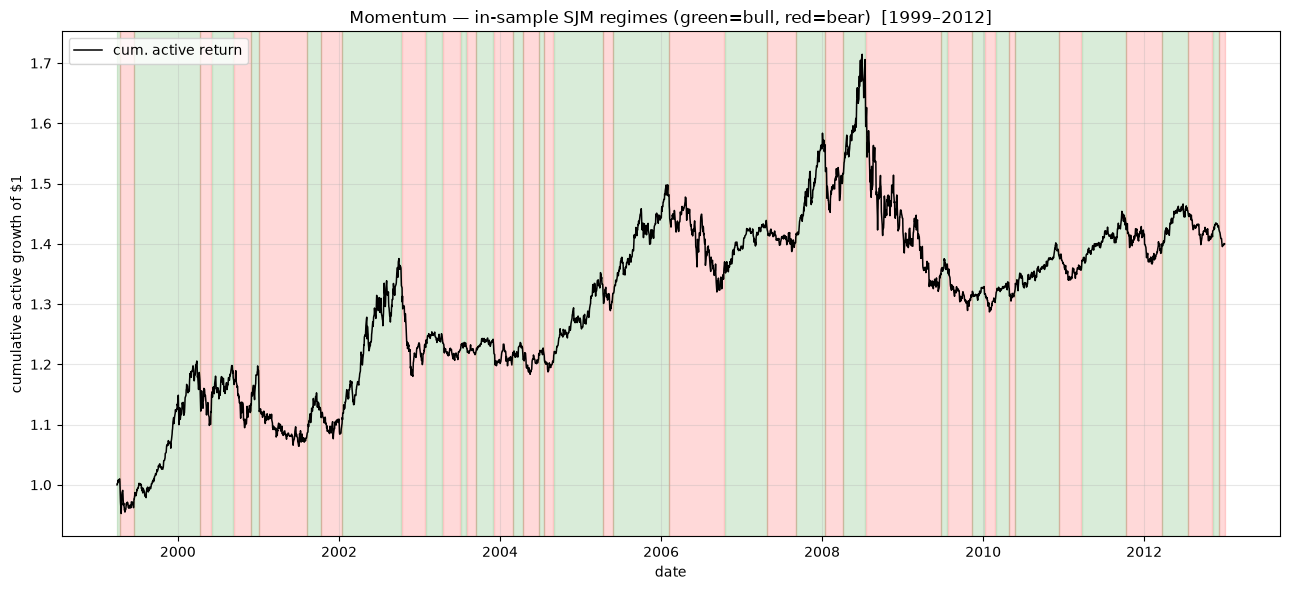

In [6]:
# 3d. plot in-sample regimes over cumulative momentum active return
cum = (1 + rtr).cumprod()
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(cum.index, cum.values, color="black", linewidth=1.1, label="cum. active return")
shade_regimes(ax, lab)
ax.set_title("Momentum — in-sample SJM regimes (green=bull, red=bear)  [1999–2012]")
ax.set_xlabel("date"); ax.set_ylabel("cumulative active growth of $1")
ax.legend(loc="upper left"); ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig("momentum_insample_regimes.png", dpi=150)
print("Saved momentum_insample_regimes.png")
plt.show()

> **PAUSE (Step 3).** Confirm regimes look persistent/sensible, bull clearly out-earns bear, and the shape resembles paper Exhibit 4.

## Step 4 — Online walk-forward with monthly refit (all 6 factors)

- **Expanding** training window from data start, **capped at 12 years** lookback (nominal min ~8y).
- **Refit the SJM monthly.** Within each month, `predict_online` infers the daily state on new data **without** refitting.
- **Bull/bear mapping** is recomputed from each refit's training data.
- **Look-ahead control:** the regime inferred at end of day T is applied from day **T+2** (`SIGNAL_DELAY=2`): the raw daily signal is shifted forward 2 trading days before use. *(The spec's general rule mentions "+1 day"; Step 4 specifies T+2, which is what is implemented. Change `SIGNAL_DELAY` to 1 if you prefer the looser rule.)*

> ⚠️ **Runtime:** ~240 monthly refits × 6 factors ≈ 1,400 SJM fits. Expect this cell to run for a number of minutes. For a quick trial set `REFIT_FREQ='Q'` in the config cell.

In [7]:
def walk_forward(factor, verbose=True):
    """Monthly-refit online walk-forward for one factor.
    Returns RAW (unshifted) daily signal and expected-annual-active-return series
    over the test period. The +SIGNAL_DELAY shift is applied later, once."""
    X   = features[factor]
    ret = active[factor]
    idx = X.index
    test_idx = idx[idx >= TEST_START]

    raw_sig = pd.Series(index=test_idx, dtype=float)   # 0/1 inferred regime
    raw_exp = pd.Series(index=test_idx, dtype=float)   # ann. expected active ret

    periods = test_idx.to_period(REFIT_FREQ)
    for p in periods.unique():
        block = test_idx[periods == p]
        b0 = block[0]
        # training window: all data strictly before this block, capped at 12y
        lb_start  = b0 - pd.DateOffset(years=MAX_LOOKBACK_YEARS)
        train_idx = idx[(idx < b0) & (idx >= lb_start)]
        Xtr, rtr  = X.loc[train_idx], ret.loc[train_idx]
        Xte       = X.loc[block]

        # scale (fit on train only), fit SJM
        Xtr_s, Xte_s, _, _ = scale_train_test(Xtr, Xte)
        model = SparseJumpModel(n_components=N_COMPONENTS, jump_penalty=JUMP_PENALTY,
                                max_feats=MAX_FEATS, random_state=RANDOM_STATE)
        model.fit(Xtr_s, ret_ser=rtr, sort_by="cumret")

        # bull/bear mapping + per-regime annual mean from THIS train window
        tr_lab  = pd.Series(np.asarray(model.predict(Xtr_s)), index=Xtr_s.index)
        mp      = bull_bear_map(tr_lab, rtr)
        rmeans  = regime_means_annual(tr_lab.map(mp), rtr)

        # online inference: feed train+block, keep the block labels (causal/filtered)
        Xfull_s = pd.concat([Xtr_s, Xte_s])
        on      = pd.Series(np.asarray(model.predict_online(Xfull_s)), index=Xfull_s.index)
        on_blk  = on.loc[block].map(mp)
        raw_sig.loc[block] = on_blk.values
        raw_exp.loc[block] = on_blk.map(rmeans).values

    if verbose:
        print(f"  {factor:9s} done: {len(periods.unique())} refits, "
              f"{int(raw_sig.notna().sum())} signal days")
    return raw_sig, raw_exp

In [8]:
# --- run walk-forward for all 6 factors (this is the slow cell) ---
raw_signals, raw_exp = {}, {}
print("Running monthly-refit walk-forward (REFIT_FREQ=%s, delay=%d) ..." % (REFIT_FREQ, SIGNAL_DELAY))
for f in FACTORS:
    raw_signals[f], raw_exp[f] = walk_forward(f)

raw_sig_df = pd.DataFrame(raw_signals)
raw_exp_df = pd.DataFrame(raw_exp)

# Apply the look-ahead-safe forward shift ONCE, then drop warmup rows.
signals    = raw_sig_df.shift(SIGNAL_DELAY).dropna().astype(int)
exp_active = raw_exp_df.shift(SIGNAL_DELAY).reindex(signals.index)

signals.to_parquet("signals.parquet")
exp_active.to_parquet("exp_active.parquet")
print("\nSaved signals.parquet", signals.shape, " and exp_active.parquet", exp_active.shape)
print("signal date range:", signals.index.min().date(), "->", signals.index.max().date())

Running monthly-refit walk-forward (REFIT_FREQ=M, delay=2) ...
  value     done: 234 refits, 5076 signal days
  size      done: 234 refits, 5076 signal days
  momentum  done: 234 refits, 5076 signal days
  quality   done: 234 refits, 5076 signal days
  lowvol    done: 234 refits, 5076 signal days
  growth    done: 234 refits, 5076 signal days

Saved signals.parquet (5074, 6)  and exp_active.parquet (5074, 6)
signal date range: 2007-01-03 -> 2026-06-15


In [9]:
# --- Step 4 sanity summary: switches/yr and % days bull, per factor ---
n_years = (signals.index[-1] - signals.index[0]).days / 365.25
summary4 = pd.DataFrame({
    "switches_per_yr": {f: round(n_switches(signals[f]) / n_years, 2) for f in FACTORS},
    "pct_days_bull":   {f: round(signals[f].mean() * 100, 1) for f in FACTORS},
})
print("Test span: %.1f years (%s -> %s)" % (n_years, signals.index.min().date(), signals.index.max().date()))
print(summary4)

Test span: 19.4 years (2007-01-03 -> 2026-06-15)
          switches_per_yr  pct_days_bull
value                3.91           45.1
size                 3.65           42.9
momentum             3.60           50.0
quality              4.11           50.3
lowvol               4.22           37.1
growth               3.24           68.8


> **PAUSE (Step 4).** Confirm switch frequency is modest (persistent regimes, not whipsawing) and bull fraction is reasonable per factor.

## Step 5 — Signal-quality evaluation (single-factor long-short, Exhibit 6)

Per factor, a relative long-factor / short-market strategy:
- **expected active return** = train-window average active return under the currently inferred regime (annualized) — this is `exp_active` from Step 4.
- **position** `weight = clip(expected_active_return / 0.05, -1, +1)` (±5%/yr → ±100%).
- **daily strategy return** = `weight × active_return(factor)` minus **5 bps per side** on position changes.

Reports annualized Sharpe per factor (paper: ~0.16–0.39, all positive) and the 6×6 strategy-return correlation matrix (paper: mostly < 0.5).

In [10]:
weights   = (exp_active / RET_CAP).clip(-1, 1)          # position per factor per day
strat_ret = pd.DataFrame(index=signals.index)
sharpe    = {}

for f in FACTORS:
    w = weights[f]
    r = active[f].reindex(w.index).fillna(0.0)          # realized active return
    turnover = w.diff().abs().fillna(w.abs())           # day-1 entry counts as turnover
    net = w * r - COST_PER_SIDE * turnover              # net daily strategy return
    strat_ret[f] = net
    sharpe[f] = net.mean() / net.std() * np.sqrt(ANNUAL)

sharpe_tbl = pd.Series(sharpe, name="ann_Sharpe").round(3)
corr = strat_ret.corr().round(2)

strat_ret.to_parquet("longshort_eval.parquet")
print("Saved longshort_eval.parquet", strat_ret.shape)
print("\n=== Annualized Sharpe per factor (paper ~0.16-0.39, all > 0) ===")
print(sharpe_tbl)
print("mean Sharpe:", round(sharpe_tbl.mean(), 3))
print("\n=== Strategy-return correlation matrix (paper: mostly < 0.5) ===")
print(corr)

Saved longshort_eval.parquet (5074, 6)

=== Annualized Sharpe per factor (paper ~0.16-0.39, all > 0) ===
value       0.458
size        0.084
momentum    0.221
quality    -0.002
lowvol      0.243
growth      0.278
Name: ann_Sharpe, dtype: float64
mean Sharpe: 0.214

=== Strategy-return correlation matrix (paper: mostly < 0.5) ===
          value  size  momentum  quality  lowvol  growth
value      1.00  0.29      0.23     0.15    0.19    0.42
size       0.29  1.00      0.11     0.16    0.19    0.28
momentum   0.23  0.11      1.00     0.05    0.19    0.26
quality    0.15  0.16      0.05     1.00    0.16    0.13
lowvol     0.19  0.19      0.19     0.16    1.00    0.25
growth     0.42  0.28      0.26     0.13    0.25    1.00


---
### Stage 4 complete
Artifacts written to this folder:
- `momentum_insample_regimes.png` — Step 3 prototype regimes.
- `signals.parquet` — daily bull(1)/bear(0) signal, 6 factors, over the test period (look-ahead-safe).
- `exp_active.parquet` — per-day annualized expected active return by inferred regime (intermediate).
- `longshort_eval.parquet` — daily long-short strategy returns used for the Sharpe / correlation check.

**STOP here.** Black-Litterman (Stage 6) is not started.

---
# Stage 4b — Per-factor cross-validated hyper-parameter tuning

Upgrades Stage 4 from fixed `jump_penalty=50, max_feats=10` to **per-factor** params chosen by **time-series CV on a 2007–2021 tune period**, with a **2022–2026 holdout that is never used for selection**.

**To run this section** you only need the fast setup cells above — run, in order: the **config cell** (imports), the **Step 1 load cell**, the **Step 2 `scale_train_test` cell**, and the **Step 3 helper-functions cell** (`bull_bear_map`, `regime_means_annual`, `n_switches`, `shade_regimes`). You can **skip the slow baseline cells** (the original Step 4 walk-forward run and Step 5) — this section regenerates its own signals.

**Holdout discipline (the whole point):**
- **TUNE** 2007-01-01 → 2021-12-31 — selects λ and `max_feats`.
- **HOLDOUT** 2022-01-01 → 2026-06-15 — never seen by tuning; honest OOS number.
- **PAPER-COMPARE** 2007-01-01 → 2024-06-30 — to line up with Exhibit 6.

Walk-forward training windows stay expanding/capped-12y; the holdout rule constrains only which period the *hyper-parameter choice* may look at. Single seed `random_state=0` this run.

### Step 1 — Setup & confirm (tuning)

In [11]:
# ----------------------------------------------------------------------
# Stage 4b config: grid, holdout periods, CV folds, tuning-speed knobs
# ----------------------------------------------------------------------
assert "features" in globals() and "scale_train_test" in globals(), \
    "Run the setup cells first: config, Step 1 load, Step 2 scale fn, Step 3 helpers."

JUMP_PENALTY_GRID = [10, 25, 50, 100, 200]
MAX_FEATS_GRID    = [5, 8, 10, 14, 17]

# Holdout split (the hyper-parameter choice may ONLY look at the tune period)
TUNE_START    = pd.Timestamp("2007-01-01")
TUNE_END      = pd.Timestamp("2021-12-31")
HOLDOUT_START = pd.Timestamp("2022-01-01")
HOLDOUT_END   = pd.Timestamp("2026-06-15")
PAPER_START   = pd.Timestamp("2007-01-01")
PAPER_END     = pd.Timestamp("2024-06-30")

# --- tuning-speed knobs (ranking only; the FINAL signal uses faithful settings) ---
TUNE_REFIT_FREQ  = "Q"   # quarterly refit during CV (vs 'M' final) -> ~3x fewer fits
TUNE_N_INIT      = 2     # inner JM random inits during CV (n_init 1..10 gave identical
                         #   regimes in a timing test; keep small & fast for ranking)
FINAL_REFIT_FREQ = "M"   # final signal: faithful monthly refit
FINAL_N_INIT     = 5     # final inner inits (results were identical at 5 vs 10)

# CV validation folds: 3-year windows rolling forward every 1 year within the tune period.
def make_folds(start, end, fold_years=3, step_years=1):
    folds, y = [], pd.Timestamp(start).year
    last = pd.Timestamp(end).year
    while y + fold_years - 1 <= last:
        folds.append((pd.Timestamp(f"{y}-01-01"), pd.Timestamp(f"{y+fold_years-1}-12-31")))
        y += step_years
    return folds

FOLDS = make_folds(TUNE_START, TUNE_END, fold_years=3, step_years=1)

print("Hyper-parameter grid: %d x %d = %d combos / factor" %
      (len(JUMP_PENALTY_GRID), len(MAX_FEATS_GRID), len(JUMP_PENALTY_GRID)*len(MAX_FEATS_GRID)))
print("  jump_penalty:", JUMP_PENALTY_GRID)
print("  max_feats   :", MAX_FEATS_GRID)
print("\nPeriods:")
print("  TUNE    :", TUNE_START.date(), "->", TUNE_END.date())
print("  HOLDOUT :", HOLDOUT_START.date(), "->", HOLDOUT_END.date())
print("  PAPER   :", PAPER_START.date(), "->", PAPER_END.date())
print("\nCV folds (%d, 3y rolling every 1y):" % len(FOLDS))
for a, b in FOLDS:
    print("   ", a.date(), "->", b.date())
print("\nData loaded:", all(f in features for f in FACTORS), "| factors:", FACTORS)

Hyper-parameter grid: 5 x 5 = 25 combos / factor
  jump_penalty: [10, 25, 50, 100, 200]
  max_feats   : [5, 8, 10, 14, 17]

Periods:
  TUNE    : 2007-01-01 -> 2021-12-31
  HOLDOUT : 2022-01-01 -> 2026-06-15
  PAPER   : 2007-01-01 -> 2024-06-30

CV folds (13, 3y rolling every 1y):
    2007-01-01 -> 2009-12-31
    2008-01-01 -> 2010-12-31
    2009-01-01 -> 2011-12-31
    2010-01-01 -> 2012-12-31
    2011-01-01 -> 2013-12-31
    2012-01-01 -> 2014-12-31
    2013-01-01 -> 2015-12-31
    2014-01-01 -> 2016-12-31
    2015-01-01 -> 2017-12-31
    2016-01-01 -> 2018-12-31
    2017-01-01 -> 2019-12-31
    2018-01-01 -> 2020-12-31
    2019-01-01 -> 2021-12-31

Data loaded: True | factors: ['value', 'size', 'momentum', 'quality', 'lowvol', 'growth']


> **PAUSE (Step 1).** Confirm the grid (25 combos), the three periods, the CV folds, and that data is loaded.

### Step 2 — Quality diagnostic (before tuning)
Fit the SJM at the OLD defaults (λ=50, max_feats=10) on the 2007–2021 tune window for **quality**, and check whether its bull/bear split is **degenerate** (state active-return gap < ~5%/yr). Also report each factor's annualized active-return vol and max drawdown — quality is a defensive factor, so a weak regime signal may be structural, not a bug.

In [12]:
# ----------------------------------------------------------------------
# Step 2: quality degeneracy check + per-factor active-return profile
# ----------------------------------------------------------------------
def max_drawdown(ret):
    cum = (1 + ret).cumprod()
    return float((cum / cum.cummax() - 1).min())

# Fit at OLD defaults on the tune window for quality
_Xq = features["quality"].loc[TUNE_START:TUNE_END]
_rq = active["quality"].loc[TUNE_START:TUNE_END]
_Xq_s, _, _, _ = scale_train_test(_Xq)
_mq = SparseJumpModel(n_components=N_COMPONENTS, jump_penalty=50.0, max_feats=10.0,
                      random_state=RANDOM_STATE)
_mq.fit(_Xq_s, ret_ser=_rq, sort_by="cumret")
_lab = pd.Series(np.asarray(_mq.predict(_Xq_s)), index=_Xq_s.index)
_mp  = bull_bear_map(_lab, _rq); _lab = _lab.map(_mp)
_rm  = regime_means_annual(_lab, _rq)
gap = _rm[1] - _rm[0]
print("QUALITY @ defaults (λ=50, mf=10) on 2007-2021:")
print("  BULL ann active = %+.2f%%   BEAR ann active = %+.2f%%   gap = %.2f%%/yr" %
      (_rm[1]*100, _rm[0]*100, gap*100))
print("  bull days=%d  bear days=%d  switches=%d" %
      (int((_lab == 1).sum()), int((_lab == 0).sum()), n_switches(_lab)))
print("  => DEGENERATE (gap < 5%/yr): signal carries little information"
      if gap < 0.05 else "  => non-degenerate split (gap >= 5%/yr)")

# Active-return vol, mean & max drawdown per factor over the tune window
print("\nPer-factor active-return profile over 2007-2021:")
prof = pd.DataFrame({
    "ann_vol_%":      {f: active[f].loc[TUNE_START:TUNE_END].std()*np.sqrt(ANNUAL)*100 for f in FACTORS},
    "ann_mean_%":     {f: active[f].loc[TUNE_START:TUNE_END].mean()*ANNUAL*100 for f in FACTORS},
    "max_drawdown_%": {f: max_drawdown(active[f].loc[TUNE_START:TUNE_END])*100 for f in FACTORS},
}).round(2).loc[FACTORS]
print(prof)

QUALITY @ defaults (λ=50, mf=10) on 2007-2021:
  BULL ann active = +6.10%   BEAR ann active = -3.90%   gap = 10.01%/yr
  bull days=1940  bear days=1975  switches=42
  => non-degenerate split (gap >= 5%/yr)

Per-factor active-return profile over 2007-2021:
          ann_vol_%  ann_mean_%  max_drawdown_%
value          5.94       -1.11          -33.51
size           4.35        0.65          -17.01
momentum       7.53        1.20          -24.94
quality        3.22        1.06           -8.05
lowvol         5.97       -0.27          -26.52
growth         4.14        3.11           -8.19


> **PAUSE (Step 2).** Note whether quality's split is degenerate and how its vol/drawdown compares — this sets expectations for whether tuning can rescue it.

### Step 3 — Per-factor CV tuning function

**Design:** for a given (λ, max_feats) we run the online walk-forward **once** over the whole tune period (2007–2021), build the single-factor long-short strategy, then score **annualized Sharpe on each 3-year fold** (rolling every 1 year → 13 folds) and average. The folds only slice the *scoring*, so the expensive signal generation runs once per combo, not once per fold. Best combo = highest **mean fold Sharpe**.

`walk_forward_params` generalizes the Step-4 `walk_forward` (same logic, reusing `scale_train_test`, `bull_bear_map`, `regime_means_annual`) but takes explicit `jump_penalty`, `max_feats`, date range, refit cadence and `n_init`.

In [13]:
# ----------------------------------------------------------------------
# Step 3: generalized walk-forward + long-short scoring + CV tuner
# ----------------------------------------------------------------------
def walk_forward_params(factor, jump_penalty, max_feats, start, end,
                        refit_freq="M", n_init=10, max_lookback_years=MAX_LOOKBACK_YEARS):
    """Generalized online walk-forward: explicit hyper-params, date range, cadence.
    Returns RAW (unshifted) 0/1 signal and expected-annual-active-return series."""
    X, ret, idx = features[factor], active[factor], features[factor].index
    test_idx = idx[(idx >= pd.Timestamp(start)) & (idx <= pd.Timestamp(end))]
    raw_sig = pd.Series(index=test_idx, dtype=float)
    raw_exp = pd.Series(index=test_idx, dtype=float)
    periods = test_idx.to_period(refit_freq)
    for p in periods.unique():
        block = test_idx[periods == p]; b0 = block[0]
        lb_start = b0 - pd.DateOffset(years=max_lookback_years)
        train_idx = idx[(idx < b0) & (idx >= lb_start)]
        Xtr, rtr = X.loc[train_idx], ret.loc[train_idx]
        Xte = X.loc[block]
        Xtr_s, Xte_s, _, _ = scale_train_test(Xtr, Xte)
        model = SparseJumpModel(n_components=N_COMPONENTS, jump_penalty=jump_penalty,
                                max_feats=max_feats, random_state=RANDOM_STATE, n_init_jm=n_init)
        model.fit(Xtr_s, ret_ser=rtr, sort_by="cumret")
        tr_lab = pd.Series(np.asarray(model.predict(Xtr_s)), index=Xtr_s.index)
        mp = bull_bear_map(tr_lab, rtr)
        rmeans = regime_means_annual(tr_lab.map(mp), rtr)
        Xfull_s = pd.concat([Xtr_s, Xte_s])
        on = pd.Series(np.asarray(model.predict_online(Xfull_s)), index=Xfull_s.index)
        on_blk = on.loc[block].map(mp)
        raw_sig.loc[block] = on_blk.values
        raw_exp.loc[block] = on_blk.map(rmeans).values
    return raw_sig, raw_exp


def longshort_net(factor, raw_exp, delay=SIGNAL_DELAY):
    """Long-short net daily return from the (shifted) expected-active-return signal."""
    w = (raw_exp.shift(delay) / RET_CAP).clip(-1, 1)
    r = active[factor].reindex(w.index).fillna(0.0)
    turnover = w.diff().abs().fillna(w.abs())
    return (w * r - COST_PER_SIDE * turnover).dropna()


def ann_sharpe(net, start=None, end=None):
    s = net.loc[start:end] if (start is not None or end is not None) else net
    return float(s.mean() / s.std() * np.sqrt(ANNUAL)) if (len(s) > 1 and s.std() > 0) else np.nan


def cv_score(factor, jump_penalty, max_feats):
    """Mean validation Sharpe across CV folds for one (factor, λ, max_feats)."""
    _, raw_exp = walk_forward_params(factor, jump_penalty, max_feats,
                                     TUNE_START, TUNE_END, TUNE_REFIT_FREQ, TUNE_N_INIT)
    net = longshort_net(factor, raw_exp)
    fold_sh = [ann_sharpe(net, a, b) for a, b in FOLDS]
    return float(np.nanmean(fold_sh)), fold_sh


def tune_factor(factor, jp_grid=None, mf_grid=None, verbose=False):
    jp_grid = JUMP_PENALTY_GRID if jp_grid is None else jp_grid
    mf_grid = MAX_FEATS_GRID if mf_grid is None else mf_grid
    rows = []
    for jp in jp_grid:
        for mf in mf_grid:
            ms, _ = cv_score(factor, jp, mf)
            rows.append({"factor": factor, "jump_penalty": jp, "max_feats": mf,
                         "mean_val_sharpe": ms})
            if verbose:
                print(f"    λ={jp:<4} mf={mf:<3} -> mean val Sharpe {ms:+.3f}")
    return pd.DataFrame(rows).sort_values("mean_val_sharpe", ascending=False).reset_index(drop=True)

In [14]:
# ----------------------------------------------------------------------
# Step 3: DRY RUN on momentum, short grid -> confirm it works + time it
# ----------------------------------------------------------------------
import time
print("DRY RUN — momentum, short grid λ∈[50,100], mf∈[10] (TUNE_REFIT_FREQ=%s, n_init=%d)"
      % (TUNE_REFIT_FREQ, TUNE_N_INIT))
_t = time.time()
_dry = tune_factor("momentum", jp_grid=[50, 100], mf_grid=[10], verbose=True)
_el = time.time() - _t
print(_dry)
_per_combo = _el / 2
print("\n%.1fs for 2 combos -> %.1fs / combo" % (_el, _per_combo))
print("Full grid: 6 factors × 25 combos = 150 combos ≈ %.1f min (≈ %.2f h) at current TUNE settings."
      % (150*_per_combo/60, 150*_per_combo/3600))
print("(Set TUNE_REFIT_FREQ='Y' for ~3x faster ranking (annual; 'A' is invalid in pandas 3), or 'M' for ~3x slower / more faithful.)")

DRY RUN — momentum, short grid λ∈[50,100], mf∈[10] (TUNE_REFIT_FREQ=Q, n_init=2)
    λ=50   mf=10  -> mean val Sharpe +0.175
    λ=100  mf=10  -> mean val Sharpe -0.063
     factor  jump_penalty  max_feats  mean_val_sharpe
0  momentum            50         10         0.175208
1  momentum           100         10        -0.063322

64.6s for 2 combos -> 32.3s / combo
Full grid: 6 factors × 25 combos = 150 combos ≈ 80.7 min (≈ 1.35 h) at current TUNE settings.
(Set TUNE_REFIT_FREQ='Y' for ~3x faster ranking (annual; 'A' is invalid in pandas 3), or 'M' for ~3x slower / more faithful.)


> **PAUSE (Step 3).** Confirm the dry run returns a Sharpe per combo and check the printed full-grid runtime estimate **before** launching the slow cell.

### Step 4 — Full tuning (SLOW: all 6 factors × 25 combos)

⚠️ **This is the long cell.** It runs 150 CV walk-forwards. Use the runtime estimate printed by the dry run above; at the default `TUNE_REFIT_FREQ='Q'` expect roughly **1–4 hours** depending on your machine. Launch it and walk away. Output is saved to `best_hyperparams.parquet`.

In [15]:
# ----------------------------------------------------------------------
# Step 4: FULL CV tuning — all 6 factors over the 25-combo grid (SLOW)
# ----------------------------------------------------------------------
import time
print("Full CV tuning over %d combos/factor ... (this is the slow cell)" %
      (len(JUMP_PENALTY_GRID)*len(MAX_FEATS_GRID)))
_t0 = time.time()
all_results, best_rows = [], []
for f in FACTORS:
    _tf = time.time()
    res = tune_factor(f)
    all_results.append(res)
    top = res.iloc[0]
    best_rows.append({"factor": f, "jump_penalty": int(top.jump_penalty),
                      "max_feats": int(top.max_feats), "val_sharpe": round(float(top.mean_val_sharpe), 3)})
    print("  %-9s best: λ=%-4d mf=%-3d  val Sharpe %+.3f   (%.1f min)" %
          (f, int(top.jump_penalty), int(top.max_feats), top.mean_val_sharpe, (time.time()-_tf)/60))

best_hp = pd.DataFrame(best_rows).set_index("factor").loc[FACTORS]
cv_results_all = pd.concat(all_results, ignore_index=True)
best_hp.reset_index().to_parquet("best_hyperparams.parquet")
cv_results_all.to_parquet("cv_results_all.parquet")
print("\nTotal tuning time: %.1f min" % ((time.time()-_t0)/60))
print("\n=== Best hyper-parameters per factor (selected on 2007-2021 ONLY) ===")
print(best_hp)
# Honesty check: flag factors whose best validation Sharpe is still ~0 or negative
weak = best_hp.index[best_hp["val_sharpe"] <= 0.05].tolist()
print("\nStructurally weak (best val Sharpe <= 0.05):", weak if weak else "none")

Full CV tuning over 25 combos/factor ... (this is the slow cell)
  value     best: λ=100  mf=5    val Sharpe +0.527   (14.1 min)
  size      best: λ=100  mf=8    val Sharpe +0.329   (13.0 min)
  momentum  best: λ=25   mf=5    val Sharpe +0.183   (13.9 min)
  quality   best: λ=100  mf=17   val Sharpe +0.018   (15.4 min)
  lowvol    best: λ=10   mf=5    val Sharpe +0.452   (14.7 min)
  growth    best: λ=100  mf=17   val Sharpe +0.564   (14.5 min)

Total tuning time: 85.6 min

=== Best hyper-parameters per factor (selected on 2007-2021 ONLY) ===
          jump_penalty  max_feats  val_sharpe
factor                                       
value              100          5       0.527
size               100          8       0.329
momentum            25          5       0.183
quality            100         17       0.018
lowvol              10          5       0.452
growth             100         17       0.564

Structurally weak (best val Sharpe <= 0.05): ['quality']


> **PAUSE (Step 4).** Review best params and validation Sharpes. Any factor with val Sharpe ≤ ~0.05 is a structurally weak signal — reported honestly, not cherry-picked.

### Step 5 — Final walk-forward with tuned params + honest evaluation

Re-run the **faithful monthly** walk-forward for each factor using its tuned (λ, max_feats) over the full 2007–2026 span, then report long-short Sharpe in three windows: **TUNE 2007-2021** (optimistic), **HOLDOUT 2022-2026** (true OOS), and **PAPER 2007-2024** (Exhibit 6 comparison), plus the strategy-return correlation matrix.

In [16]:
# ----------------------------------------------------------------------
# Step 5a: final monthly walk-forward with TUNED params over 2007-2026
# ----------------------------------------------------------------------
import time
best_hp = pd.read_parquet("best_hyperparams.parquet").set_index("factor").loc[FACTORS]
print("Final monthly walk-forward with tuned params (FINAL_REFIT_FREQ=%s, n_init=%d) ..."
      % (FINAL_REFIT_FREQ, FINAL_N_INIT))
_t0 = time.time()
raw_sig_t, raw_exp_t = {}, {}
for f in FACTORS:
    jp = float(best_hp.loc[f, "jump_penalty"]); mf = float(best_hp.loc[f, "max_feats"])
    raw_sig_t[f], raw_exp_t[f] = walk_forward_params(f, jp, mf, TEST_START, HOLDOUT_END,
                                                     FINAL_REFIT_FREQ, FINAL_N_INIT)
    print("  %-9s done (λ=%g, mf=%g)" % (f, jp, mf))
print("Final walk-forward time: %.1f min" % ((time.time()-_t0)/60))

sig_t = pd.DataFrame(raw_sig_t); exp_t = pd.DataFrame(raw_exp_t)
signals_tuned    = sig_t.shift(SIGNAL_DELAY).dropna().astype(int)
exp_active_tuned = exp_t.shift(SIGNAL_DELAY).reindex(signals_tuned.index)
signals_tuned.to_parquet("signals_tuned.parquet")
exp_active_tuned.to_parquet("exp_active_tuned.parquet")
print("Saved signals_tuned.parquet", signals_tuned.shape, "and exp_active_tuned.parquet")

Final monthly walk-forward with tuned params (FINAL_REFIT_FREQ=M, n_init=5) ...
  value     done (λ=100, mf=5)
  size      done (λ=100, mf=8)
  momentum  done (λ=25, mf=5)
  quality   done (λ=100, mf=17)
  lowvol    done (λ=10, mf=5)
  growth    done (λ=100, mf=17)
Final walk-forward time: 30.7 min
Saved signals_tuned.parquet (5074, 6) and exp_active_tuned.parquet


In [17]:
# ----------------------------------------------------------------------
# Step 5b: long-short eval across the three windows vs baseline & paper
# ----------------------------------------------------------------------
strat_t = pd.DataFrame({f: longshort_net(f, exp_t[f]) for f in FACTORS})

baseline = {"value": 0.46, "size": 0.08, "momentum": 0.22, "quality": -0.00, "lowvol": 0.24, "growth": 0.28}
paper    = {"value": 0.39, "size": 0.20, "momentum": 0.16, "quality": 0.21, "lowvol": 0.30, "growth": 0.37}

tbl = pd.DataFrame({
    "tune_07_21":    {f: ann_sharpe(strat_t[f], TUNE_START, TUNE_END) for f in FACTORS},
    "holdout_22_26": {f: ann_sharpe(strat_t[f], HOLDOUT_START, HOLDOUT_END) for f in FACTORS},
    "paper_07_24":   {f: ann_sharpe(strat_t[f], PAPER_START, PAPER_END) for f in FACTORS},
    "baseline":      baseline,
    "paper_exh6":    paper,
}).round(3).loc[FACTORS]

def verdict(row):
    if row["paper_07_24"] <= 0.05:           return "weak signal (≈0 even tuned)"
    helped = row["paper_07_24"] > row["baseline"] + 0.02
    holds  = row["holdout_22_26"] > 0.05
    if helped and holds:        return "tuning helped, holds OOS"
    if helped and not holds:    return "helped in-sample, weak OOS"
    if (not helped) and holds:  return "~baseline, positive OOS"
    return "no improvement"
tbl["verdict"] = tbl.apply(verdict, axis=1)

strat_t.to_parquet("longshort_eval_tuned.parquet")
print("=== Long-short Sharpe: tuned vs baseline vs paper ===")
print(tbl)
print("\nmean holdout Sharpe (true OOS):", round(tbl["holdout_22_26"].mean(), 3))
print("\n=== Strategy-return correlation (paper window 2007-2024; paper: mostly < 0.5) ===")
print(strat_t.loc[PAPER_START:PAPER_END].corr().round(2))

=== Long-short Sharpe: tuned vs baseline vs paper ===
          tune_07_21  holdout_22_26  paper_07_24  baseline  paper_exh6                      verdict
value          0.483          0.571        0.289      0.46        0.39      ~baseline, positive OOS
size           0.327         -0.196        0.300      0.08        0.20   helped in-sample, weak OOS
momentum       0.180          0.752        0.322      0.22        0.16     tuning helped, holds OOS
quality        0.038         -0.111        0.023     -0.00        0.21  weak signal (≈0 even tuned)
lowvol         0.398          0.568        0.400      0.24        0.30     tuning helped, holds OOS
growth         0.444          0.192        0.480      0.28        0.37     tuning helped, holds OOS

mean holdout Sharpe (true OOS): 0.296

=== Strategy-return correlation (paper window 2007-2024; paper: mostly < 0.5) ===
          value  size  momentum  quality  lowvol  growth
value      1.00  0.31      0.20     0.13    0.17    0.45
size      

---
### Stage 4b complete — artifacts
- `best_hyperparams.parquet` — selected (λ, max_feats) per factor + validation Sharpe (chosen on 2007–2021 only).
- `cv_results_all.parquet` — full 25-combo CV grid per factor.
- `signals_tuned.parquet`, `exp_active_tuned.parquet` — tuned daily regime signal over 2007–2026.
- `longshort_eval_tuned.parquet` — tuned long-short daily returns.

**Holdout was never used to select params.** The `holdout_22_26` column is the honest out-of-sample read; `paper_07_24` lines up with Exhibit 6.

**STOP here.** Black-Litterman (Stage 6) is not started.